##  1. Import Libraries & Load Dataset

In [139]:
# ─── FIX: matplotlib backend must be set BEFORE importing pyplot ──────────
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

In [ ]:


DATA_PATH = 'adult.csv'
TARGET_COL = 'income'

TEST_SIZE = 0.20
RANDOM_STATE = 42

OUTLIER_COLS = ['capital-gain', 'capital-loss', 'fnlwgt', 'hours-per-week', 'age']

XGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.005,
    'max_depth': 8,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'scale_pos_weight': 1.1,
    'gamma': 0.3,
    'reg_alpha': 0.5,
    'reg_lambda': 2.0,
    'random_state': RANDOM_STATE,
    'use_label_encoder': False,
    'eval_metric': 'aucpr',
}

MODEL_PATH = 'xgb_model.pkl'
SCALER_PATH = 'scaler.pkl'
FEATURES_PATH = 'feature_columns.pkl'

DEFAULT_FEATURE_FLAGS = {
    'workclass_Private': 1,
    'education_HS-grad': 1,
    'occupation_Prof-specialty': 1,
    'relationship_Not-in-family': 1,
    'race_White': 1,
    'gender_Male': 1,
    'native-country_United-States': 1,
}

In [141]:
df = pd.read_csv(DATA_PATH)
raw_df = df.copy()
print(f'Shape: {df.shape}')
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


---
##  2. Data Exploration (EDA)

In [142]:
print(df.info())
print('\n')
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


                age        fnlwgt  educational-num  capital-gain  \
c

Number of records                : 48,842
Individuals with income  > $50K  : 11,687  (23.93%)
Individuals with income <= $50K  : 37,155  (76.07%)


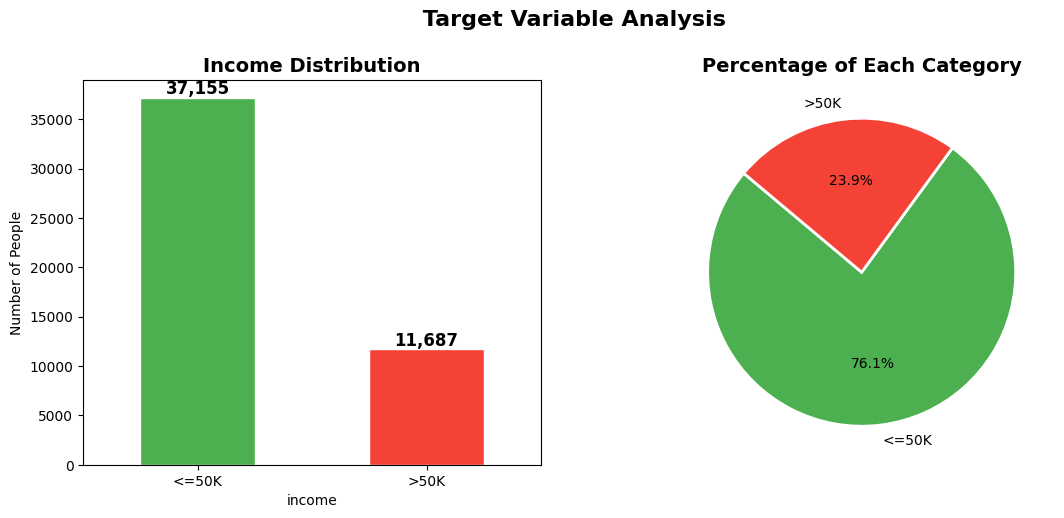

In [143]:
# ─── Target Distribution ─────────────────────────────────────────────────
n_rec         = df.shape[0]
n_greater_50k = df[df[TARGET_COL] == '>50K'].shape[0]
n_most_50k    = df[df[TARGET_COL] == '<=50K'].shape[0]
per_greater   = (n_greater_50k / n_rec) * 100
per_most      = (n_most_50k   / n_rec) * 100

print(f'Number of records                : {n_rec:,}')
print(f'Individuals with income  > $50K  : {n_greater_50k:,}  ({per_greater:.2f}%)')
print(f'Individuals with income <= $50K  : {n_most_50k:,}  ({per_most:.2f}%)')

income_counts = df[TARGET_COL].value_counts()
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
income_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Income Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of People')
axes[0].tick_params(rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage of Each Category', fontsize=14, fontweight='bold')
plt.suptitle(' Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()

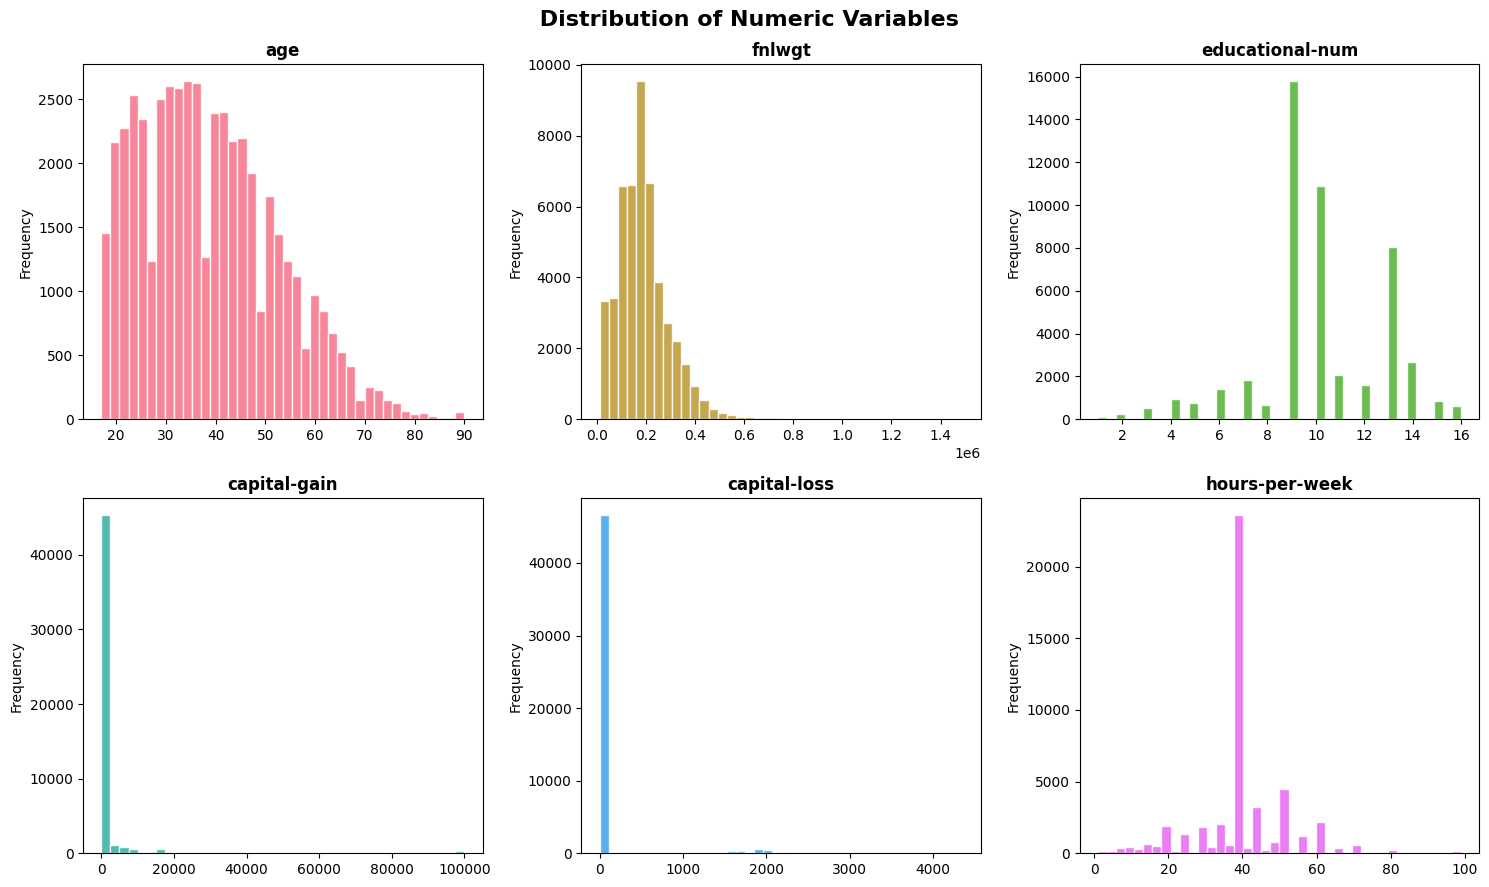

In [144]:
# ─── Numeric Distributions ───────────────────────────────────────────────
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = sns.color_palette('husl', len(num_cols))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color=palette[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frequency')
plt.suptitle(' Distribution of Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [145]:
# ─── Skewness Check ──────────────────────────────────────────────────────
num_col = df.select_dtypes(include=np.number).columns
print('Skewness (sorted):')
print(df[num_col].skew().sort_values(ascending=False))

Skewness (sorted):
capital-gain       11.894659
capital-loss        4.569809
fnlwgt              1.438892
age                 0.557580
hours-per-week      0.238750
educational-num    -0.316525
dtype: float64


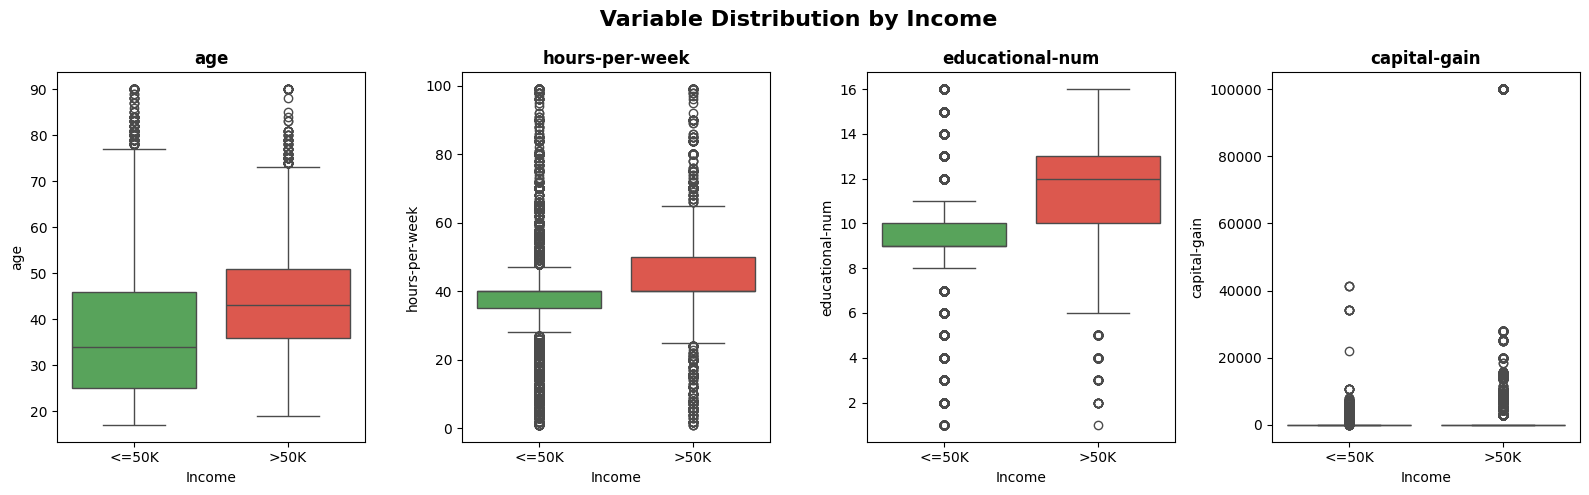

In [146]:
# ─── Boxplots by Income ──────────────────────────────────────────────────
possible_cols = ['age', 'hours-per-week', 'educational-num', 'education-num', 'capital-gain']
key_cols = [c for c in possible_cols if c in df.columns][:4]
fig, axes = plt.subplots(1, len(key_cols), figsize=(16, 5))
if len(key_cols) == 1:
    axes = [axes]
for i, col in enumerate(key_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i],
                palette=['#4CAF50', '#F44336'])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Income')
plt.suptitle(' Variable Distribution by Income', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  3. Data Preprocessing

In [147]:
# ─── 3.1 Remove Duplicates ───────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicates found: {dups}')
if dups > 0:
    df = df.drop_duplicates()
    print(f'After removing duplicates: {df.shape}')

Duplicates found: 52
After removing duplicates: (48790, 15)


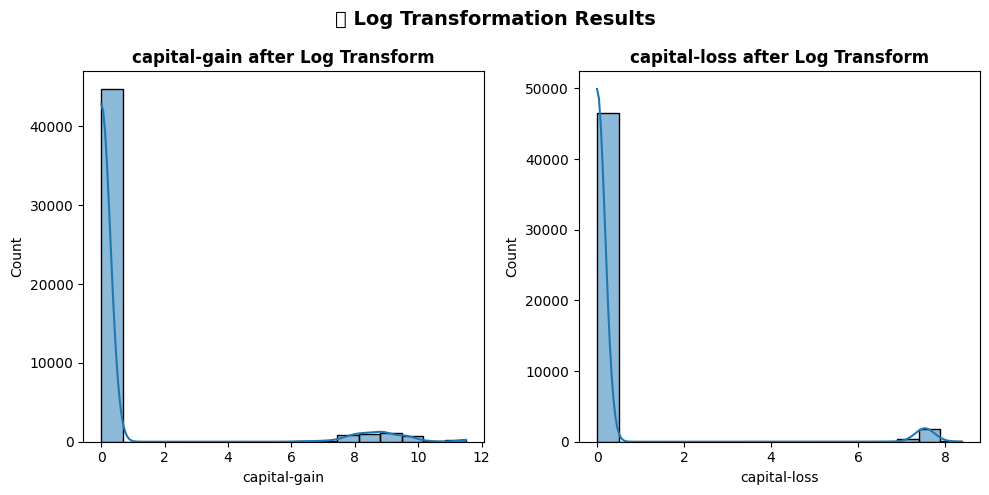

 Log transformation applied to: ['capital-gain', 'capital-loss']


In [148]:
# ─── 3.2 Log Transformation (capital-gain & capital-loss) ─────────────────
# Matches preprocessing.py → apply_log_transform()
skewed_cols = ['capital-gain', 'capital-loss']
skewed_cols = [c for c in skewed_cols if c in df.columns]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(10, 5))
if len(skewed_cols) == 1:
    axes = [axes]
for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} after Log Transform', fontsize=12, fontweight='bold')
plt.suptitle('💥 Log Transformation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(' Log transformation applied to:', skewed_cols)

In [149]:
# ─── 3.3 Encoding ─────────────────────────────────────────────────────────
# Matches preprocessing.py → encode_features()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_for_dummies = [c for c in cat_cols if c != TARGET_COL]

df = pd.get_dummies(df, columns=cat_for_dummies, drop_first=True)
df[TARGET_COL] = df[TARGET_COL].map({'<=50K': 0, '>50K': 1})
df = df.astype(int)

print(f'Shape after encoding: {df.shape}')
print(f'Target values       : {df[TARGET_COL].unique()}')

Shape after encoding: (48790, 101)
Target values       : [0 1]


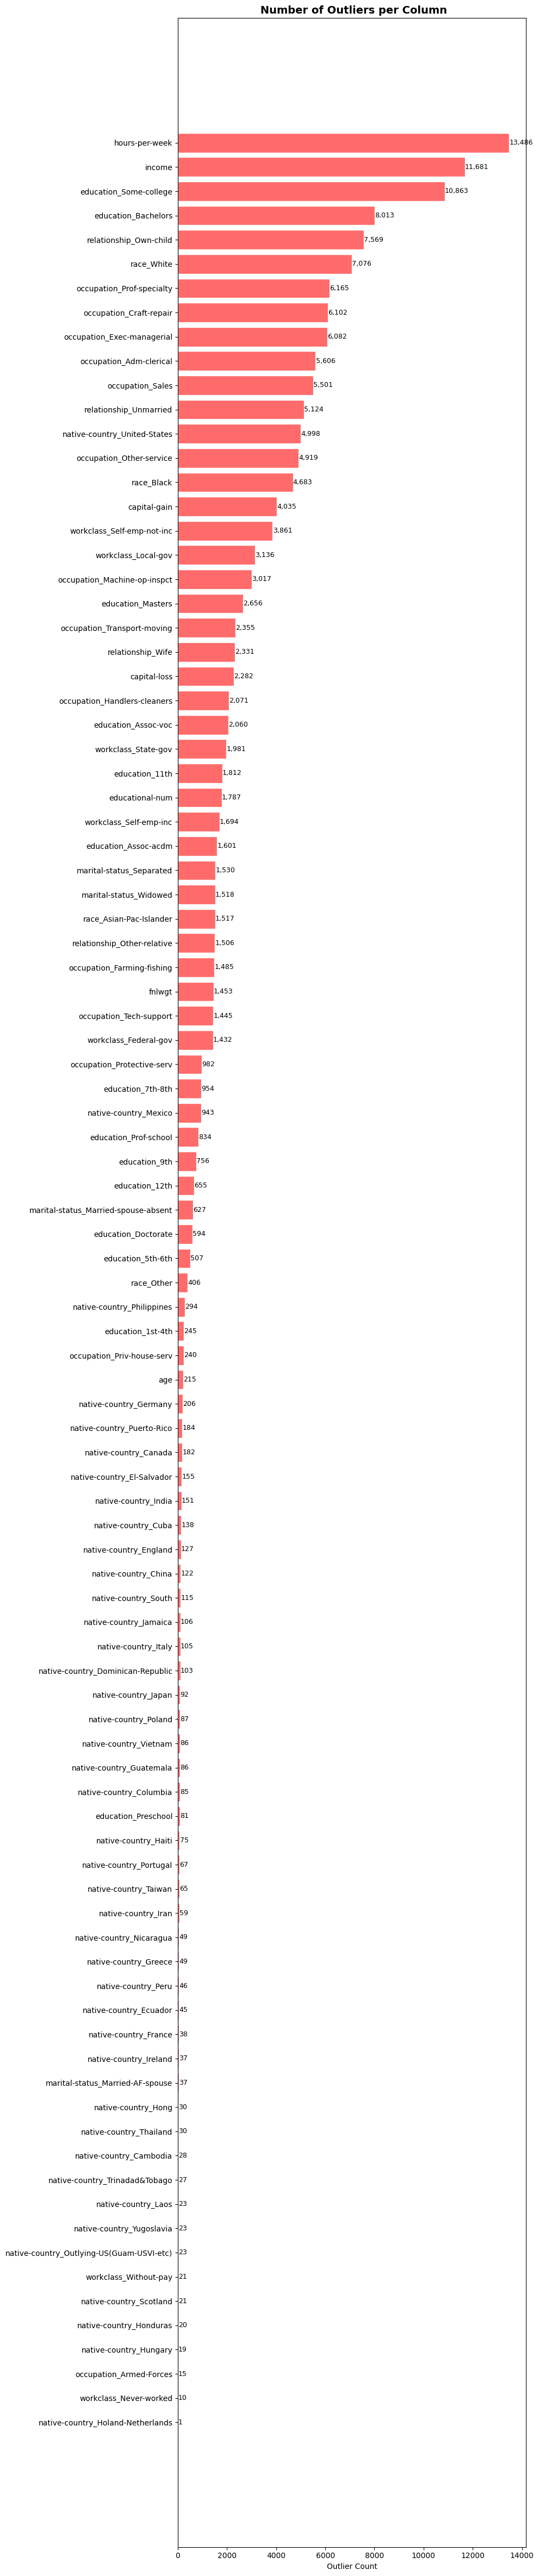

 Outlier clipping done


In [150]:
# ─── 3.4 Outlier Detection & IQR Clipping ────────────────────────────────
# Matches preprocessing.py → detect_outliers() + treat_outliers()
outlier_cols = [c for c in OUTLIER_COLS if c in df.columns]
outliers_report = {}
for col in df.select_dtypes(include=['int', 'float']).columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    count  = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if count > 0:
        outliers_report[col] = count

report_df = (pd.DataFrame(list(outliers_report.items()),
                           columns=['Column', 'Outlier Count'])
             .sort_values('Outlier Count', ascending=True))

if not report_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(report_df)*0.5)))
    bars = ax.barh(report_df['Column'], report_df['Outlier Count'],
                   color='#FF6B6B', edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=9)
    ax.set_title(' Number of Outliers per Column', fontsize=14, fontweight='bold')
    ax.set_xlabel('Outlier Count')
    plt.tight_layout()
    plt.show()

# Apply IQR clipping
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print(' Outlier clipping done')

In [151]:
# ─── 3.5 Train/Test Split ────────────────────────────────────────────────
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts()}')

Train size : (39032, 100)
Test size  : (9758, 100)
Train target distribution:
income
0    29687
1     9345
Name: count, dtype: int64


In [152]:
# ─── 3.6 SMOTE (handle class imbalance) ──────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE → {X_train_res.shape}')
print(f'Class distribution after SMOTE:\n{pd.Series(y_train_res).value_counts()}')

After SMOTE → (59374, 100)
Class distribution after SMOTE:
income
1    29687
0    29687
Name: count, dtype: int64


In [153]:
# ─── 3.7 Scaling ─────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)
feature_names  = X_train.columns.tolist()

print(' Scaling done')
print(f'Feature count: {len(feature_names)}')

 Scaling done
Feature count: 100


---
##  5. Model Training — XGBoost

In [154]:
# FIX: use_label_encoder removed — matches model.py → train_model()
model = XGBClassifier(**XGB_PARAMS)
model.fit(X_train_scaled, y_train_res)
print(' Model trained successfully')

 Model trained successfully


---
##  6. Model Evaluation

In [155]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
report  = classification_report(y_test, y_pred, output_dict=True)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print('=' * 50)
print('MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'Accuracy    : {acc:.4f}  ({acc:.2%})')
print(f'F1 Score    : {f1:.4f}')
print(f'AUC Score   : {roc_auc:.4f}')
print(f'Precision   : {report["1"]["precision"]:.4f}')
print(f'Recall      : {report["1"]["recall"]:.4f}')
print()
print('Improvement over Naive Predictor:')
print(f'  Accuracy  +{(acc - naive_accuracy):.2%}')
print(f'  F1 Score  +{(f1 - naive_f1):.4f}')

MODEL EVALUATION RESULTS
Accuracy    : 0.8331  (83.31%)
F1 Score    : 0.6455
AUC Score   : 0.8900
Precision   : 0.6565
Recall      : 0.6348

Improvement over Naive Predictor:
  Accuracy  +7.25%
  F1 Score  +0.6455


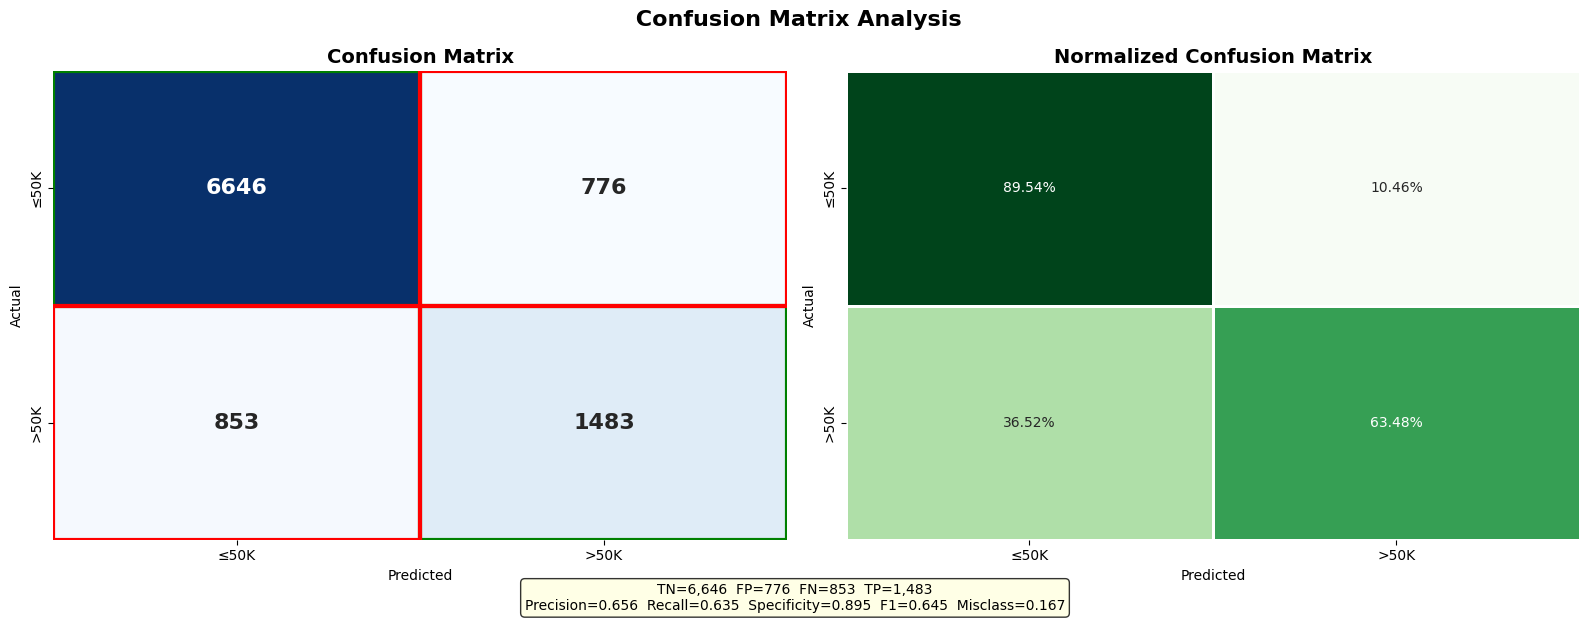


Detailed Metrics:
  TN=6,646  FP=776  FN=853  TP=1,483
  Precision    = 0.6565
  Recall       = 0.6348
  Specificity  = 0.8954
  Misclass Rate= 0.1669
 Chart saved → plot_confusion_matrix.png


In [156]:
# ─── Confusion Matrix (Advanced) ─────────────────────────────────────────
# Matches model.py → plot_confusion_matrix()
cm             = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
precision_v    = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_v       = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity    = tn / (tn + fp) if (tn + fp) > 0 else 0
misclass       = (fp + fn) / cm.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['≤50K', '>50K'], yticklabels=['≤50K', '>50K'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
for (r, c), color in [((0,0),'green'), ((1,1),'green'), ((0,1),'red'), ((1,0),'red')]:
    axes[0].add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor=color, lw=3))

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['≤50K', '>50K'], yticklabels=['≤50K', '>50K'],
            linewidths=1, linecolor='white', cbar=False)
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

details = (f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}\n'
           f'Precision={precision_v:.3f}  Recall={recall_v:.3f}  '
           f'Specificity={specificity:.3f}  F1={f1:.3f}  Misclass={misclass:.3f}')
fig.text(0.5, -0.02, details, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(' Confusion Matrix Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nDetailed Metrics:')
print(f'  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'  Precision    = {precision_v:.4f}')
print(f'  Recall       = {recall_v:.4f}')
print(f'  Specificity  = {specificity:.4f}')
print(f'  Misclass Rate= {misclass:.4f}')
print(' Chart saved → plot_confusion_matrix.png')

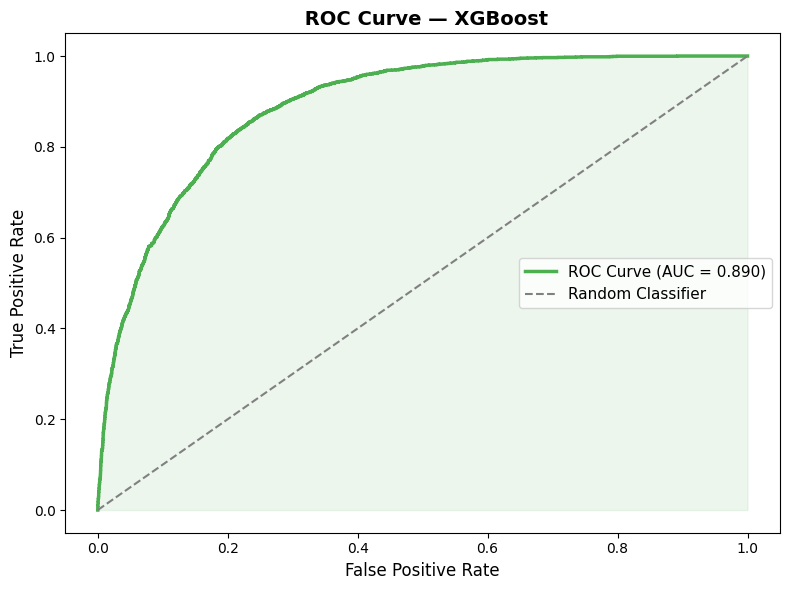

In [157]:
# ─── ROC Curve ───────────────────────────────────────────────────────────
# Matches model.py → plot_roc_curve()
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#4CAF50', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
        label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4CAF50')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(' ROC Curve — XGBoost', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [158]:
# ─── Classification Report ───────────────────────────────────────────────
print(classification_report(y_test, y_pred,
      target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.89      7422
        >50K       0.66      0.63      0.65      2336

    accuracy                           0.83      9758
   macro avg       0.77      0.77      0.77      9758
weighted avg       0.83      0.83      0.83      9758



---
##  7. Feature Importance

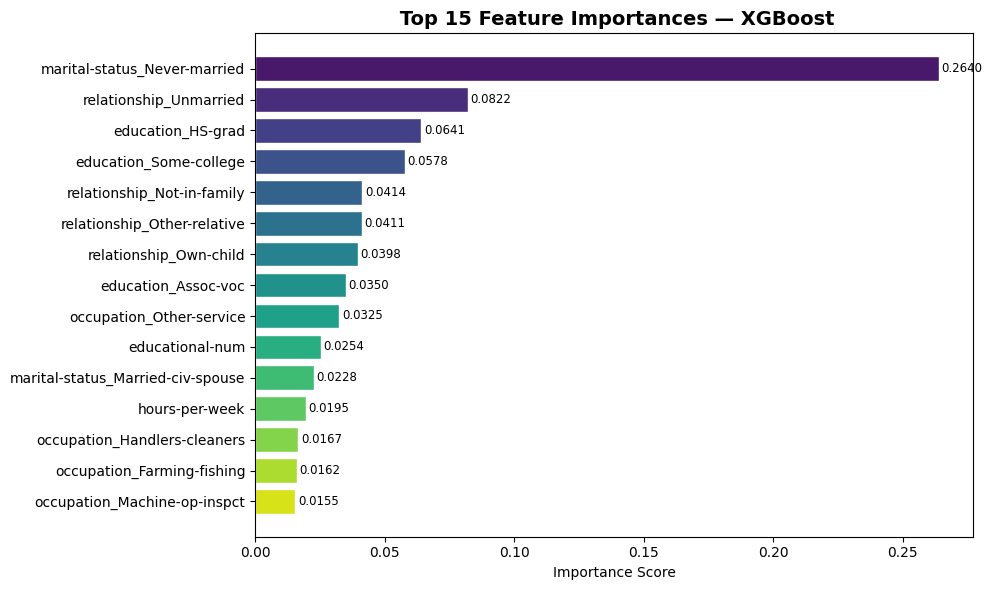


Top 5 features:
                     Feature  Importance
marital-status_Never-married    0.263964
      relationship_Unmarried    0.082165
           education_HS-grad    0.064147
      education_Some-college    0.057773
  relationship_Not-in-family    0.041402


In [159]:
# Matches model.py → plot_feature_importance()
top_n = 15
importance_df = (
    pd.DataFrame({'Feature': feature_names,
                  'Importance': model.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(top_n)
)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('viridis', len(importance_df))
bars = ax.barh(importance_df['Feature'].iloc[::-1],
               importance_df['Importance'].iloc[::-1],
               color=palette[::-1], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8.5)
ax.set_title(f' Top {top_n} Feature Importances — XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importance_df.head(5).to_string(index=False))

---
##  8. Feature Selection — Top 5

In [160]:
# Matches model.py → select_top5_features() + evaluate_top5()
top5_features = importance_df.head(5)['Feature'].tolist()
print('Top 5 Features selected:')
for i, f in enumerate(top5_features, 1):
    print(f'  {i}. {f}')

# Get column indices in scaled array
idx_top5     = [feature_names.index(f) for f in top5_features]
X_train_top5 = X_train_scaled[:, idx_top5]
X_test_top5  = X_test_scaled[:, idx_top5]

# Train XGBoost on Top-5 only
xgb_top5 = XGBClassifier(**XGB_PARAMS)
xgb_top5.fit(X_train_top5, y_train_res)
y_pred_top5 = xgb_top5.predict(X_test_top5)

acc_top5 = accuracy_score(y_test, y_pred_top5)
f1_top5  = f1_score(y_test, y_pred_top5)

print()
print('=' * 55)
print(f'XGBoost (All Features) → Accuracy: {acc:.3f} | F1: {f1:.3f}')
print(f'XGBoost (Top-5 Only)   → Accuracy: {acc_top5:.3f} | F1: {f1_top5:.3f}')
print('=' * 55)

drop = (acc - acc_top5) * 100
print(f'Accuracy drop with Top-5 only: {drop:.1f}%')

if acc_top5 >= 0.85:
    print(' Top-5 features retain most predictive power!')
else:
    print('  Performance dropped — more features needed.')

Top 5 Features selected:
  1. marital-status_Never-married
  2. relationship_Unmarried
  3. education_HS-grad
  4. education_Some-college
  5. relationship_Not-in-family

XGBoost (All Features) → Accuracy: 0.833 | F1: 0.645
XGBoost (Top-5 Only)   → Accuracy: 0.753 | F1: 0.564
Accuracy drop with Top-5 only: 8.0%
  Performance dropped — more features needed.
